### 1. Import Libraries

To build the breast cancer classification model, several essential Python libraries are imported. The `os` library is used for file handling and accessing image folders, while `cv2` (OpenCV) helps in reading and preprocessing images. `numpy` handles numerical data efficiently, and `skimage.feature.hog` extracts important texture and shape features using the HOG descriptor. The `scikit-learn` modules provide tools for model training (`SVC`), data splitting (`train_test_split`), and performance evaluation (`accuracy_score`, `confusion_matrix`, `classification_report`). Finally, `matplotlib.pyplot` is used for visualizing the model’s performance through graphs and confusion matrices.


In [1]:

import os
import cv2
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from skimage.feature import hog
import matplotlib.pyplot as plt

### 2. Load Dataset
In this section, the dataset is loaded from three folders: normal, benign, and malignant. Each folder represents a different class of breast tissue images. The load_images_from_folder() function reads all images from each folder, converts them to grayscale, and resizes them to 128×128 pixels for uniformity. The images are stored in list X, while their corresponding class labels are stored in list y. Finally, both lists are converted into NumPy arrays to make them suitable for machine learning model training and processing.

In [2]:

def load_images_from_folder(folder, label):
    images, labels = [], []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (128, 128))  # Resize
            images.append(img)
            labels.append(label)
    return images, labels

base_path = r'C:\Users\rizwa\Desktop\Minor Project\dataset'
classes = ["normal", "benign", "malignant"]
X, y = [], []

for idx, cls in enumerate(classes):
    imgs, labels = load_images_from_folder(os.path.join(base_path, cls), idx)
    X.extend(imgs)
    y.extend(labels)

X = np.array(X)
y = np.array(y)

### 3. Feature Extraction

In this step, each image is transformed into a set of numerical features using the Histogram of Oriented Gradients (HOG) descriptor. HOG captures the shape and texture patterns in the image by computing gradients and their orientations in small cells. For each image in the dataset X, the HOG features are calculated with 9 orientations, a cell size of 8×8 pixels, and a block size of 2×2 cells. The resulting feature vectors are stored in hog_features and converted into a NumPy array, creating a structured format suitable for training the SVM classifier.

In [3]:

hog_features = []
for img in X:
    fd, _ = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    hog_features.append(fd)

hog_features = np.array(hog_features)

### 4. Train-Test Split
Before training the model, the dataset is divided into training and testing sets using train_test_split. Here, 80% of the data is used for training the SVM classifier to learn patterns, and 20% is reserved for testing to evaluate the model’s performance on unseen data. Setting random_state=42 ensures that the split is reproducible, so results remain consistent across different runs.

In [4]:

X_train, X_test, y_train, y_test = train_test_split(hog_features, y, test_size=0.2, random_state=42)

### 5. Train SVM Model

In this step, a Support Vector Machine (SVM) classifier is created using an RBF (Radial Basis Function) kernel, which allows the model to handle non-linear relationships in the data. The parameters C=10 and gamma=0.01 control the regularization and the influence of individual data points, respectively. The probability=True option enables probability estimates for predictions. The model is then trained on the X_train features and y_train labels, allowing it to learn patterns that distinguish between normal, benign, and malignant breast tissue images.

In [5]:

svm_model = SVC(kernel='rbf', C=10, gamma=0.01, probability=True)
svm_model.fit(X_train, y_train)

SVC(C=10, gamma=0.01, probability=True)

### 6. Evaluation

After training, the SVM model’s performance is assessed using the testing dataset. The model predicts labels for X_test, and the predictions are compared with the true labels y_test. The accuracy score measures the overall correctness of the predictions, while the classification report provides detailed metrics—such as precision, recall, and F1-score—for each class (normal, benign, malignant), giving a comprehensive view of the model’s effectiveness in classifying breast tissue images.

In [6]:

y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=classes))

Accuracy: 0.9171597633136095

Classification Report:
               precision    recall  f1-score   support

      normal       0.96      1.00      0.98       154
      benign       0.94      0.82      0.88       186
   malignant       0.86      0.95      0.90       167

    accuracy                           0.92       507
   macro avg       0.92      0.92      0.92       507
weighted avg       0.92      0.92      0.92       507



### 7. Prediction Function

This function allows the trained SVM model to predict the class of a new breast tissue image. Given the image_path, the image is read in grayscale and resized to 128×128 pixels. HOG features are extracted from the image to create a numerical feature vector compatible with the trained model. The function then uses the SVM to predict the class label (normal, benign, or malignant) and also returns the probability of each class, providing both the predicted category and the model’s confidence in its prediction.

In [7]:

def predict_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    fd, _ = hog(img, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), visualize=True)
    fd = fd.reshape(1, -1)
    prediction = svm_model.predict(fd)[0]
    probability = svm_model.predict_proba(fd)[0]
    return classes[prediction], probability

### 8. Testing

In this step, the user can test the trained SVM model on a new image by providing its file path. The predict_image() function is called with this path, and it returns the predicted class label and the probability scores for each category. The results are then printed, showing both the predicted class (normal, benign, or malignant) and a probability distribution that indicates the model’s confidence in each possible class.

Predicted Class: benign
Class Probabilities: {'normal': 0.0015408157589627872, 'benign': 0.9853894360670249, 'malignant': 0.013069748174012465}


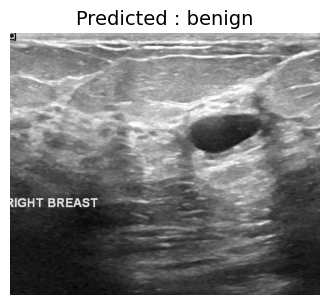

In [8]:

import matplotlib.pyplot as plt
import cv2

test_image_path = input("Enter Image Path: ")
label, probs = predict_image(test_image_path)
print(f"Predicted Class: {label}")
print(f"Class Probabilities: {dict(zip(classes, probs))}")

img = cv2.imread(test_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Predicted : {label}", fontsize=14, color='black')
plt.axis('off')
plt.show()


### 10. Confusion Matrix
The confusion matrix provides a detailed view of the SVM model’s performance by showing the number of correct and incorrect predictions for each class. Using seaborn, the matrix is visualized with a heatmap where rows represent the actual classes and columns represent the predicted classes. The annotated numbers make it easy to see how many images were correctly classified as normal, benign, or malignant, and how many were misclassified, offering insight into the model’s strengths and weaknesses.

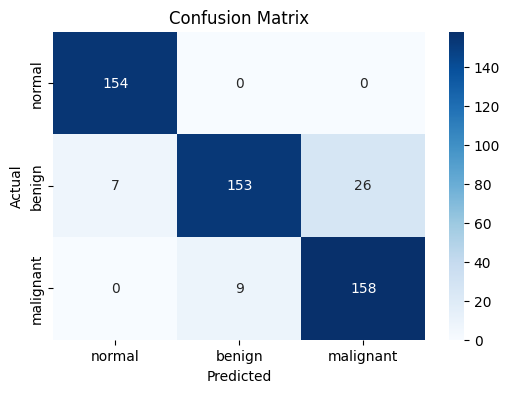

In [9]:

import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [10]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']